In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import zipfile
import torch.optim as optim
import zipfile

In [ ]:
with zipfile.ZipFile('/content/Flowers.zip', 'r') as zip_ref:
  zip_ref.extractall('.')

In [ ]:
transforms_data = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

In [ ]:
train_data = datasets.ImageFolder('/content/Flowers/train', transform=transforms_data)
test_data = datasets.ImageFolder('/content/Flowers/test', transform=transforms_data)

In [ ]:
classes = train_data.classes
classes

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

In [ ]:
len(classes)

5

In [ ]:
train = DataLoader(train_data, batch_size=64, shuffle=True)
test = DataLoader(test_data, batch_size=64)

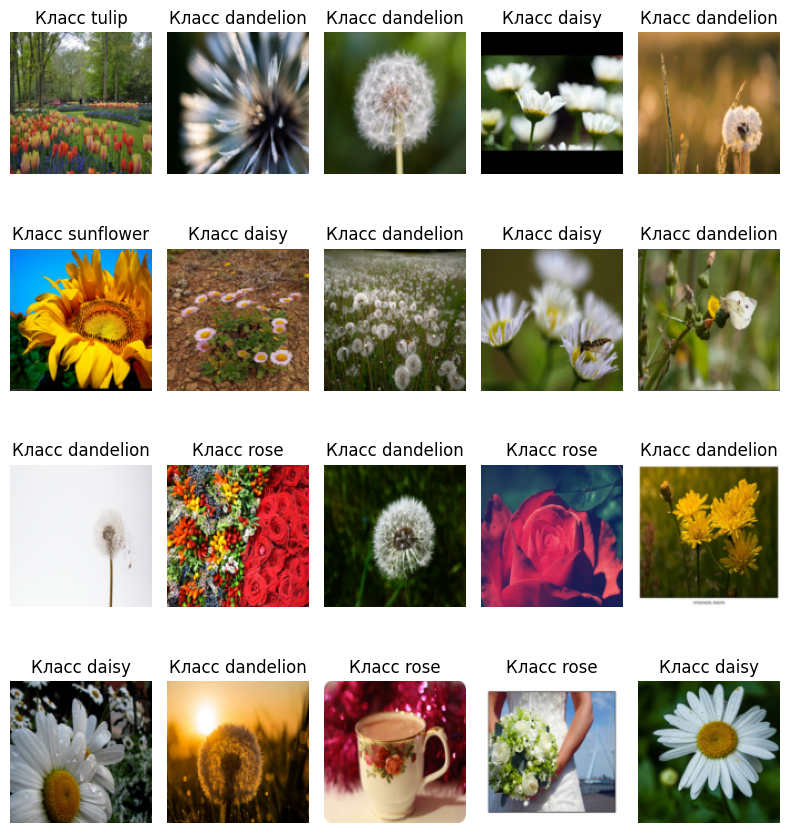

In [ ]:
image, label = next(iter(train))
plt.figure(figsize=(8, 10))
for i in range(20):
  plt.subplot(4, 5, i+1)
  plt.imshow(image[i].permute(1, 2, 0))
  plt.title(f'Класс {classes[label[i]]}')
  plt.axis('off')
  plt.tight_layout()
plt.show()

In [ ]:
class FlowersVGG(nn.Module):
  def __init__(self):
    super().__init__()
    self.first = nn.Sequential(
        nn.Conv2d(3, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(64, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(128, 128, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(128, 256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(256, 256, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),

        nn.Conv2d(256, 512, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.Conv2d(512, 512, kernel_size=3, padding=1),
        nn.ReLU(),
        nn.MaxPool2d(2),


  )

    self.second = nn.Sequential(
        nn.Flatten(),
        nn.Linear(512 * 8 * 8, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 5)
    )

  def forward(self, flower):
      flower = self.first(flower)
      flower = self.second(flower)
      return flow

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
model = FlowersVGG().to(device)

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [ ]:
for epoch in range(30):
  model.train()
  total_loss = 0
  for x_batch, y_batch in train:
    x_batch, y_batch = x_batch.to(device), y_batch.to(device)
    y_pred = model(x_batch)
    loss = loss_fn(y_pred, y_batch)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    total_loss += loss.item()

  print(f'эпоха: {epoch+1}, Потери: {round(total_loss, 2)}')

эпоха: 1, Потери: 69.16
эпоха: 2, Потери: 67.8
эпоха: 3, Потери: 61.7
эпоха: 4, Потери: 54.61
эпоха: 5, Потери: 50.85
эпоха: 6, Потери: 48.53
эпоха: 7, Потери: 47.69
эпоха: 8, Потери: 45.44
эпоха: 9, Потери: 45.25
эпоха: 10, Потери: 42.03
эпоха: 11, Потери: 40.78
эпоха: 12, Потери: 38.63
эпоха: 13, Потери: 38.35
эпоха: 14, Потери: 34.97
эпоха: 15, Потери: 35.17
эпоха: 16, Потери: 32.66
эпоха: 17, Потери: 30.56
эпоха: 18, Потери: 30.09
эпоха: 19, Потери: 26.98
эпоха: 20, Потери: 25.39
эпоха: 21, Потери: 24.52
эпоха: 22, Потери: 24.02
эпоха: 23, Потери: 19.89
эпоха: 24, Потери: 18.66
эпоха: 25, Потери: 16.66
эпоха: 26, Потери: 16.23
эпоха: 27, Потери: 16.35
эпоха: 28, Потери: 14.83
эпоха: 29, Потери: 12.04
эпоха: 30, Потери: 14.69


In [ ]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for x_batch, y_batch in train:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)

        y_pred = model(x_batch)
        predicted = torch.argmax(y_pred, dim=1)

        total += y_batch.size(0)
        correct += (predicted == y_batch).sum().item()

accuracy = 100 * correct / total
print(f"Точность модели на тестовых данных: {round(a  ccuracy, 2)}%")

Точность модели на тестовых данных: 94.65%


In [ ]:
torch.save(model.state_dict(), 'flowers_model.pth')